<a href="https://colab.research.google.com/github/JamesTan44181/DLI-Group-Assignment/blob/main/GroupAssignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup


In [ ]:
import numpy as np
import pandas as pd
import time
import gdown
import glob
from sklearn.preprocessing import OneHotEncoder
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
import os
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import cohen_kappa_score
from sklearn.utils import class_weight
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.ensemble import RandomForestClassifier
from sklearn.exceptions import UndefinedMetricWarning
import warnings

start = time.time()
np.random.seed(42)
tf.random.set_seed(42)

# Data Loading

The dataset is download from UNB but colab cannot directly access to the link. Hence, we upload into a public google drive to download by using the url. (IDS 2017 | Datasets | Research | Canadian Institute for Cybersecurity | UNB, n.d.)

In [ ]:
# target file
data_dir = "CIC_IDS2017"
if not os.path.exists(data_dir):
    # Download zip file of dataset for whole dataset
    file_id = "1pMMlyzmJNvURynMO0_WztdIhl6oFPASo"
    url = f"https://drive.google.com/uc?id={file_id}"
    output = "CIC-IDS2017.zip"

    # Download for only Monday-WorkingHours.csv
    #file_id = "1p9vawaAKIMof7zZY2QP-AIZEYN0k9c1u"
    #url = f"https://drive.google.com/uc?id={file_id}"
    #output = "CICIDS2017.zip"
    gdown.download(url, output, quiet=False)

    # extract
    !unzip -q CIC-IDS2017.zip -d CIC_IDS2017
else:
    print("Dataset already exists, skip downloading.")

files = glob.glob("CIC_IDS2017/MachineLearningCVE/*.csv")

sampled_dfs = []

for file in files:
    print("Processing:", file)
    df = pd.read_csv(file)

    # get 40,000 in each csv
    df_sample = df.sample(n=min(40000, len(df)), random_state=42)

    sampled_dfs.append(df_sample)

# combine the data we need to used
df_combined = pd.concat(sampled_dfs, ignore_index=True)

print("Total rows after sampling:", len(df_combined))

# save
df_combined.to_csv("CICIDS2017_sampled.csv", index=False)
print("Saved to CICIDS2017_sampled.csv")

Dataset already exists, skip downloading.
Processing: CIC_IDS2017/MachineLearningCVE/Monday-WorkingHours.pcap_ISCX.csv
Processing: CIC_IDS2017/MachineLearningCVE/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Processing: CIC_IDS2017/MachineLearningCVE/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Processing: CIC_IDS2017/MachineLearningCVE/Friday-WorkingHours-Morning.pcap_ISCX.csv
Processing: CIC_IDS2017/MachineLearningCVE/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Processing: CIC_IDS2017/MachineLearningCVE/Tuesday-WorkingHours.pcap_ISCX.csv
Processing: CIC_IDS2017/MachineLearningCVE/Wednesday-workingHours.pcap_ISCX.csv


KeyboardInterrupt: 

In [ ]:
# To combine all CSV and show the first five rows
#csv_files = glob.glob('CIC_IDS2017/MachineLearningCVE/Monday-WorkingHours.csv')
#df_list = [pd.read_csv(f) for f in csv_files]
#df = pd.concat(df_list, ignore_index=True)
#df.head()
# To get only Monday-WorkingHours dataset on CIC-IDS2017 dataset
df_combined.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,80,5271779,3,1,12,0,6,0,4.000000,3.464102,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,443,153756,10,5,1140,943,901,0,114.000000,280.179308,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,443,312614,15,10,974,7387,469,0,64.933333,134.265976,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,53,62774,2,2,64,200,32,32,32.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,123,68044766,2,2,96,96,48,48,48.000000,0.000000,...,20,44475.0,0.0,44475,44475,67955579.0,0.0,67955579,67955579,BENIGN


# Pre-processing

Data Cleaning

In [ ]:
# Show the total row
print("Total rows before cleaning:", len(df_combined))

# Check duplicates
print("Total duplicate rows:", df_combined.duplicated().sum())

# Delete the duplicated row
df_combined.drop_duplicates(inplace=True)
#print("Total rows after dropping duplicates:", len(df))
# The total rows after dropping duplicates is same with total rows before, so no need this process.

# Check Infinite value
numeric_df = df_combined.select_dtypes(include=[np.number])
print("Total infinite values:", np.isinf(numeric_df.values).sum())

# Process the infinite value
df_combined = df_combined.replace([np.inf, -np.inf], np.nan)

# Check missing values
#print("Total missing values:", df.isna().sum().sum())
#print("Missing values per column (if any):")
#print(df.isna().sum())

# Fill the missing value
# Since there are huge dataset, we use pandas fillna to process this.
# Pandas fillna is faster than SimpleImputer
numeric_cols = df_combined.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df_combined[col].isna().sum() > 0:
       df_combined[col] = df_combined[col].fillna(df_combined[col].median())

# Remove all the space after and before the columns name
df_combined.rename(columns=lambda x: x.strip(), inplace=True)

# Confirm the label types
print("Unique Labels:", df_combined['Label'].unique())

# Convert the unreadable text to readable
df_combined['Label'] = df_combined['Label'].replace({
    'Web Attack � Brute Force': 'Web Attack - Brute Force',
    'Web Attack � XSS': 'Web Attack - XSS',
    'Web Attack � Sql Injection': 'Web Attack - Sql Injection'
})

df_combined.to_csv("CIC_IDS2017_cleaned.csv", index=False)
print("Data cleaning complete, saved to CIC_IDS2017_cleaned.csv")
print("Total rows after cleaning:", len(df_combined))

Total rows before cleaning: 320000
Total duplicate rows: 14931
Total infinite values: 364
Unique Labels: ['BENIGN' 'Infiltration' 'DDoS' 'Bot' 'PortScan' 'SSH-Patator'
 'FTP-Patator' 'DoS Hulk' 'DoS Slowhttptest' 'DoS GoldenEye'
 'DoS slowloris' 'Heartbleed' 'Web Attack � Brute Force'
 'Web Attack � XSS' 'Web Attack � Sql Injection']
Data cleaning complete, saved to CIC_IDS2017_cleaned.csv
Total rows after cleaning: 305069


Balance Classes

In [ ]:
# Total the label sample
class_counts = df_combined['Label'].value_counts()
print("Original class distribution:")
print(class_counts)

# Find the label types which is existed the highest time
majority_class = class_counts.idxmax()
print("Majority class:", majority_class)

#Separate the highest existed label and anothers
df_majority = df_combined[df_combined['Label'] == majority_class]
df_minority = df_combined[df_combined['Label'] != majority_class]

#Undersample the majority class to match the total of the minority class (to maintain balance).
df_majority_downsampled = resample(df_majority,
                                   replace=False,
                                   n_samples=len(df_minority),
                                   random_state=42)

df_balanced = pd.concat([df_majority_downsampled, df_minority])
print("Balanced class distribution:")
print(df_balanced['Label'].value_counts())

Original class distribution:
Label
BENIGN                        249186
DDoS                           22808
PortScan                       19680
DoS Hulk                       10285
FTP-Patator                      600
DoS GoldenEye                    565
Bot                              385
SSH-Patator                      378
Web Attack - Brute Force         364
DoS slowloris                    325
DoS Slowhttptest                 318
Web Attack - XSS                 164
Web Attack - Sql Injection         5
Infiltration                       4
Heartbleed                         2
Name: count, dtype: int64
Majority class: BENIGN
Balanced class distribution:
Label
BENIGN                        55883
DDoS                          22808
PortScan                      19680
DoS Hulk                      10285
FTP-Patator                     600
DoS GoldenEye                   565
Bot                             385
SSH-Patator                     378
Web Attack - Brute Force        364
Do

Label Encoding using One-Hot Encoding because the model we choose is neural network

In [ ]:
# Print out all the column name
#print(df.columns.tolist())

# Remove all the space after and before the columns name
#df.rename(columns=lambda x: x.strip(), inplace=True)

# Confirm again the columns name
#print(df.columns.tolist())

# Confirm the label types
#print("Unique Labels:", df['Label'].unique())

# Convert the unreadable text to readable
#df['Label'] = df['Label'].replace({
#    'Web Attack � Brute Force': 'Web Attack - Brute Force',
#    'Web Attack � XSS': 'Web Attack - XSS',
#    'Web Attack � Sql Injection': 'Web Attack - Sql Injection'
#})
# Above put in data cleaning places

ohe = OneHotEncoder(sparse_output=False)
labels = ohe.fit_transform(df_balanced[['Label']])
print("First 5 one-hot encoded labels:")
print(labels[:5])
print("Classes:", ohe.categories_)


First 5 one-hot encoded labels:
[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]
Classes: [array(['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk',
       'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'Heartbleed',
       'Infiltration', 'PortScan', 'SSH-Patator',
       'Web Attack - Brute Force', 'Web Attack - Sql Injection',
       'Web Attack - XSS'], dtype=object)]


Document features

In [ ]:
feature_names = df_balanced.drop(columns=['Label']).columns.tolist()
print("\nNumber of features:", len(feature_names))
print("Feature names (前10个示例):", feature_names[:10])

class_counts = df_balanced['Label'].value_counts()
print("\nClass distribution table:")
print(class_counts)


Number of features: 78
Feature names (前10个示例): ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std']

Class distribution table:
Label
BENIGN                        55883
DDoS                          22808
PortScan                      19680
DoS Hulk                      10285
FTP-Patator                     600
DoS GoldenEye                   565
Bot                             385
SSH-Patator                     378
Web Attack - Brute Force        364
DoS slowloris                   325
DoS Slowhttptest                318
Web Attack - XSS                164
Web Attack - Sql Injection        5
Infiltration                      4
Heartbleed                        2
Name: count, dtype: int64


Features scaling

In [ ]:
# Except label, all is features
features = df_balanced.drop(columns=['Label'])
labels = ohe.fit_transform(df_balanced[['Label']])

# Standardize scaler
scaler = StandardScaler()

# Do scaling for all features
features_scaled = scaler.fit_transform(features)

print("Shape of features:", features_scaled.shape)
print("Shape of labels:", labels.shape)

#print("Done in:", time.time() - start, "seconds")

Shape of features: (111766, 78)
Shape of labels: (111766, 15)


Train-test split

In [ ]:
# Drop Label
features = df_combined.drop(columns=['Label'])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    features_scaled,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)


Train shape: (89412, 78) (89412, 15)
Test shape: (22354, 78) (22354, 15)


# Model

Define DNN （Group）

In [ ]:
dropout_rate = 0.3
neurons = [128, 64, 32]

model = Sequential()
# Define input with Input layer
model.add(Input(shape=(X_train.shape[1],)))

# First hidden layer
model.add(Dense(neurons[0], activation='relu'))
model.add(Dropout(dropout_rate))

# Second hidden layer
model.add(Dense(neurons[1], activation='relu'))
model.add(Dropout(dropout_rate))

# Third hidden layer
model.add(Dense(neurons[2], activation='relu'))
model.add(Dropout(dropout_rate))

# Output layer
model.add(Dense(y_train.shape[1], activation='softmax'))

model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 128)            │        10,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 15)             │           495 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,943 (81.81 KB)

 Trainable params: 20,943 (81.81 KB)

 Non-trainable params: 0 (0.00 B)

Define Randome Forest (CY)

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=42
)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9954817929677016


LTSM+ANN Chuah Shao Ern TP075348

Epoch 1/10
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 64s 44ms/step - accuracy: 0.7174 - loss: 0.9053 - val_accuracy: 0.9176 - val_loss: 0.2713 - learning_rate: 0.0010
Epoch 2/10
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 81s 43ms/step - accuracy: 0.9275 - loss: 0.2441 - val_accuracy: 0.9451 - val_loss: 0.1597 - learning_rate: 0.0010
Epoch 3/10
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 84s 45ms/step - accuracy: 0.9394 - loss: 0.1908 - val_accuracy: 0.9465 - val_loss: 0.1668 - learning_rate: 0.0010
Epoch 4/10
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 81s 44ms/step - accuracy: 0.9442 - loss: 0.1691 - val_accuracy: 0.9600 - val_loss: 0.1254 - learning_rate: 0.0010
Epoch 5/10
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 49s 44ms/step - accuracy: 0.9501 - loss: 0.1499 - val_accuracy: 0.9640 - val_loss: 0.1167 - learning_rate: 0.0010
Epoch 6/10
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 83s 45ms/step - accuracy: 0.9529 - loss: 0.1409 - val_accuracy: 0.9578 - val_loss: 0.1279 - learning_rate: 0.0010
Epoch 7/10
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 50s 45ms/step - accura

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


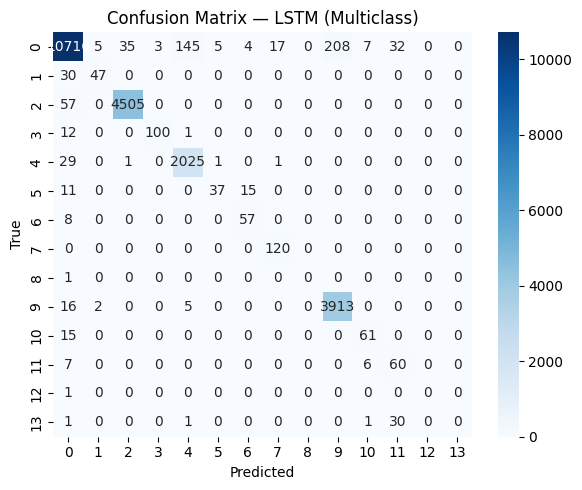

ROC-AUC (OvR): nan


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


In [ ]:
# --- Build MULTICLASS LSTM (15-way softmax) ---
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import numpy as np

num_classes = y_tr.shape[1]   # should be 15

lstm_model = Sequential([
    LSTM(64, input_shape=(X_tr_3d.shape[1], 1), return_sequences=False),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

earlystop = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
reducelr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

# --- TRAIN ---
history = lstm_model.fit(
    X_tr_3d, y_tr,
    validation_data=(X_val_3d, y_val),
    epochs=10, batch_size=64,
    callbacks=[earlystop, reducelr],
    verbose=1
)

# --- EVALUATE (multiclass) ---
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report, roc_auc_score

y_proba = lstm_model.predict(X_te_3d)                 # (N, 15)
y_pred  = y_proba.argmax(axis=1)                      # class indices
y_true  = y_test.argmax(axis=1)                       # class indices

acc = accuracy_score(y_true, y_pred)
prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)

print("📊 Core Metrics (Macro)")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")

print("\nClassification report (per class):")
print(classification_report(y_true, y_pred, digits=4))

cm = confusion_matrix(y_true, y_pred)
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix — LSTM (Multiclass)")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout(); plt.show()




# Training

Set hyperparameters, compile the model, and fit it to the data.

In [ ]:
# Set hyperparameters
learning_rate = 0.001
batch_size = 32
epochs = 10

# Compile
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# Fit data
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=epochs,
    batch_size=batch_size,
    verbose=1
)

Epoch 1/10
 509/2795 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7041 - loss: 1.0547

KeyboardInterrupt: 

# Evaluation

Prediction

In [ ]:
# Model prediction
y_pred_probs = model.predict(X_test)

# Convert to class labels
# Predict Label
y_pred = y_pred_probs.argmax(axis=1)
# Real label
y_true = y_test.argmax(axis=1)

699/699 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


Evaluation Metrics

Accuracy: 0.9737407175449584
Macro F1 Score: 0.7061345041440943

Classification Report (Per-class metrics):

              precision    recall  f1-score   support

           0       0.99      0.96      0.98     11177
           1       0.82      0.61      0.70        77
           2       1.00      1.00      1.00      4562
           3       0.96      0.96      0.96       113
           4       0.92      0.99      0.95      2057
           5       0.90      0.90      0.90        63
           6       0.95      0.88      0.91        65
           7       0.93      1.00      0.96       120
           9       0.00      0.00      0.00         1
          10       0.95      1.00      0.97      3936
          11       0.90      0.95      0.92        76
          12       0.49      0.82      0.62        73
          13       0.00      0.00      0.00         1
          14       0.00      0.00      0.00        33

    accuracy                           0.97     22354
   macro avg       0.70  

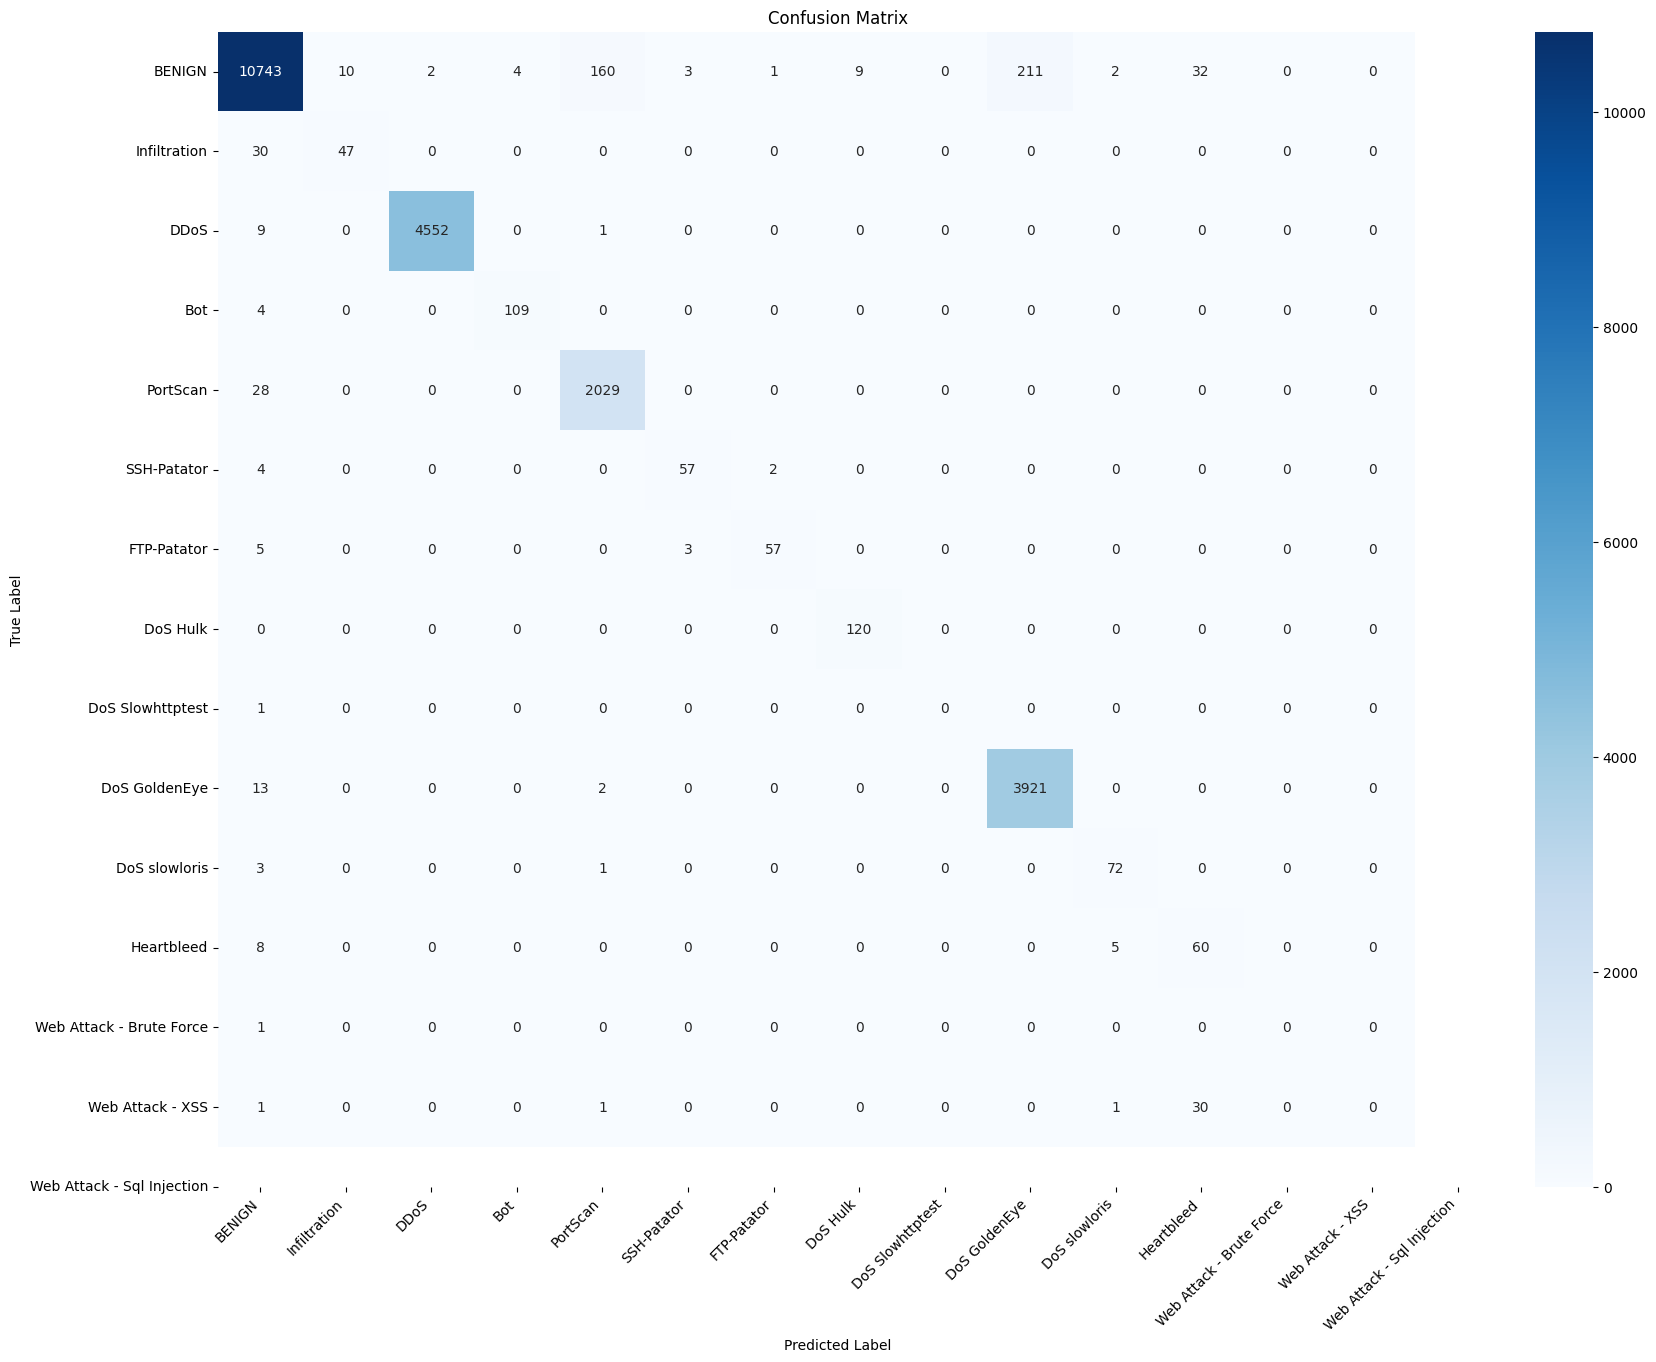

Weighted F1 Score: 0.9733322308536202
Cohen's Kappa Score: 0.9610425005636856


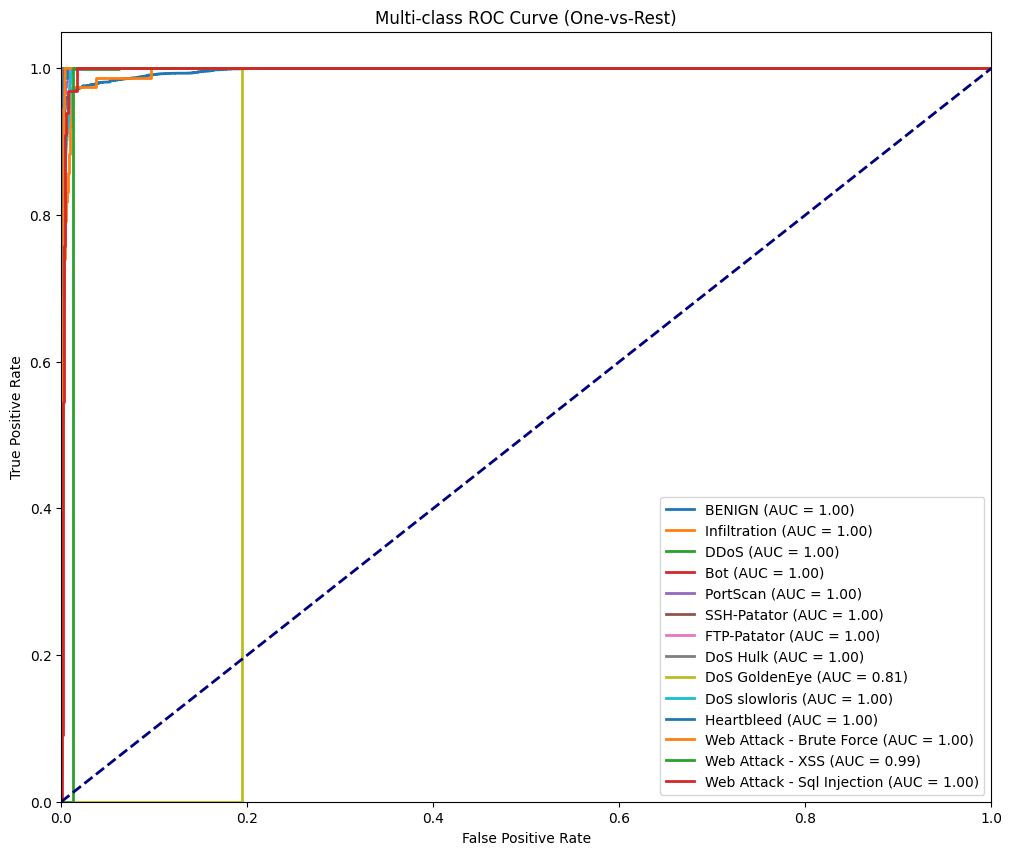

In [ ]:
warnings.filterwarnings(action='ignore', category=UndefinedMetricWarning)

# 1. Accuracy
accuracy = accuracy_score(y_true, y_pred)
print("Accuracy:", accuracy)

# 2. Macro F1
macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
print("Macro F1 Score:", macro_f1)

# 3. Per-class Precision, Recall, F1
print("\nClassification Report (Per-class metrics):\n")
print(classification_report(y_true, y_pred, zero_division=0))

# 4. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
class_names = df_combined['Label'].unique()

plt.figure(figsize=(20, 15))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={"size": 10})
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# 5. Weighted F1 Score
weighted_f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
print("Weighted F1 Score:", weighted_f1)

# 6. Cohen’s Kappa Score
kappa = cohen_kappa_score(y_true, y_pred)
print("Cohen's Kappa Score:", kappa)

# 7. Multi-class ROC Curve (One-vs-Rest)
# y_test should be one-hot encoded
y_true_bin = y_test
n_classes = y_true_bin.shape[1]
label_names = df_combined['Label'].unique()

plt.figure(figsize=(12, 10))
for i in range(n_classes):
    if y_true_bin[:, i].sum() == 0 or np.all(y_pred_probs[:, i] == 0):
        continue
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{label_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curve (One-vs-Rest)')
plt.legend(loc="lower right")
plt.show()

# Save

Save the model

In [ ]:
# Save model
model.save("cicids2017_model.keras")
print("Model saved as cicids2017_model.keras")

# Save test features
pd.DataFrame(X_test, columns=feature_names).to_csv("X_test.csv", index=False)
print("Test features saved as X_test.csv")

# Save test labels (convert from one-hot to integer)
y_labels = np.argmax(y_test, axis=1)
pd.DataFrame(y_labels, columns=['Label']).to_csv("y_test_labels.csv", index=False)
print("Test labels saved as y_test_labels.csv")

# Save feature names for reference
pd.DataFrame(feature_names, columns=['Feature']).to_csv("feature_names.csv", index=False)
print("Feature names saved as feature_names.csv")

Model saved as cicids2017_model.keras
Test features saved as X_test.csv
Test labels saved as y_test_labels.csv
Feature names saved as feature_names.csv


Verdict

In [ ]:
print(f"Verdict: Achieved Accuracy = {accuracy:.4f}, Macro F1 = {macro_f1:.4f}, target largely met with strong overall performance, though minority-class detection could be further improved.")

Verdict: Achieved Accuracy = 0.9737, Macro F1 = 0.7068, target largely met with strong overall performance, though minority-class detection could be further improved.
